In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
data=pd.read_csv('C:\Machine Learning\multiple-linear-regression-sample-dataset\study_hours.csv')
data.head()


,StudyHours,ExtraParticipation,PapersPracticed,PreviousMarks,SleepingHours,PerformanceIndex
0,5,No,2,69,8,51
1,2,Yes,8,46,4,20
2,7,Yes,5,56,7,46
3,6,Yes,5,42,8,28
4,7,No,6,53,4,41


In [3]:
data.describe()

,StudyHours,PapersPracticed,PreviousMarks,SleepingHours,PerformanceIndex
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,4.583300,69.445700,6.530600,55.224800
std,2.589309,2.867348,17.343152,1.695863,19.212558
min,1.000000,0.000000,40.000000,4.000000,10.000000
25%,3.000000,2.000000,54.000000,5.000000,40.000000
50%,5.000000,5.000000,69.000000,7.000000,55.000000
75%,7.000000,7.000000,85.000000,8.000000,71.000000
max,9.000000,9.000000,99.000000,9.000000,100.000000


In [4]:
data.shape

(10000, 6)

In [5]:
data.count()

StudyHours            10000
ExtraParticipation    10000
PapersPracticed       10000
PreviousMarks         10000
SleepingHours         10000
PerformanceIndex      10000
dtype: int64

In [6]:
# drop duplicates
data=data.drop_duplicates()

In [7]:
data.shape

(9873, 6)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   StudyHours          9873 non-null   int64 
 1   ExtraParticipation  9873 non-null   object
 2   PapersPracticed     9873 non-null   int64 
 3   PreviousMarks       9873 non-null   int64 
 4   SleepingHours       9873 non-null   int64 
 5   PerformanceIndex    9873 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 539.9+ KB


In [9]:
# checking nan values in the dataset
data.isnull().sum()

StudyHours            0
ExtraParticipation    0
PapersPracticed       0
PreviousMarks         0
SleepingHours         0
PerformanceIndex      0
dtype: int64

In [10]:
#Mapping the values of "ExtraParticipation" column
data['ExtraParticipation']=data['ExtraParticipation'].map({'Yes':1,'No':0})

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9873 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   StudyHours          9873 non-null   int64
 1   ExtraParticipation  9873 non-null   int64
 2   PapersPracticed     9873 non-null   int64
 3   PreviousMarks       9873 non-null   int64
 4   SleepingHours       9873 non-null   int64
 5   PerformanceIndex    9873 non-null   int64
dtypes: int64(6)
memory usage: 539.9 KB


Model Selection,Training,Evaluation

In [12]:
x = data.drop(columns=['PerformanceIndex'])
y = data['PerformanceIndex']

In [13]:
# Splitting the data into training and testing data
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
# Fitting the linear regression model
model = sklearn.linear_model.LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# Model Prediction
y_pred = model.predict(x_test)

In [16]:
# Model Evaluation
mse = mean_squared_error(y_test,y_pred)
rmse = mse** 0.5
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [17]:
print(f"mse: {mse}")
print(f"rmse: {rmse}")
print(f"mae: {mae}")
print(f"r2: {r2}")

mse: 4.248296188699436
rmse: 2.0611395364456615
mae: 1.6298335748270334
r2: 0.988340624449475


Actual values v/s Predicted values

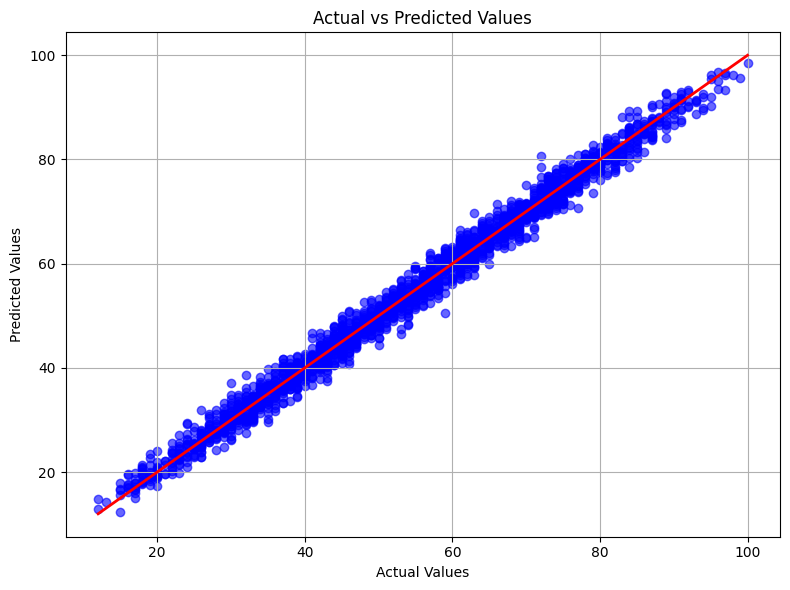

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='-', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.tight_layout()
plt.show()

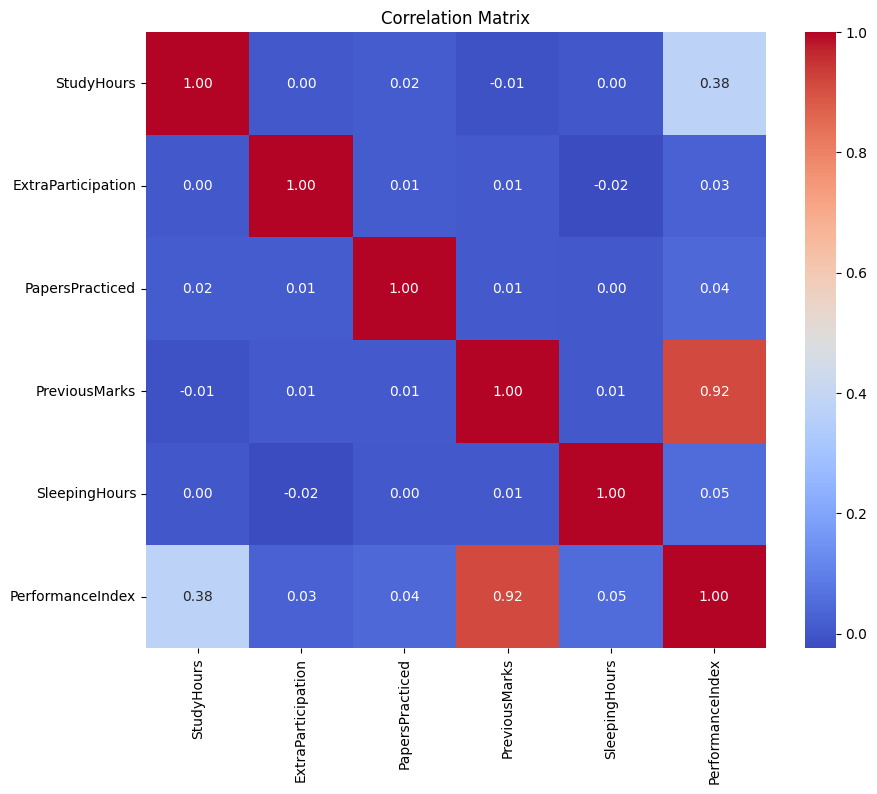

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()